<a href="https://colab.research.google.com/github/123hawaa/ML-AdaptiveBeamforming-5G-MassiveMIMO/blob/master/train_Machine_learning_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Step 3: Load CSV
df = pd.read_csv('/content/DATA_shuffled.csv')
df = df.sample(frac=1).reset_index(drop=True)
print("✅ Data loaded and shuffled with shape:", df.shape)
df.head()


✅ Data loaded and shuffled with shape: (3024, 11)


,BS,Sector,UserID,AssignedPRBs,Rk_Mbps,MOk,maximum_throughput,TotalPower_W,BSTotalPower_W,Select_Subarrays,SelectedSubarray
0,59,3,2122,10,28,4,1.805026e+06,0.267608,16.872158,3,3.0
1,14,3,494,12,48,6,1.985521e+06,0.869037,9.600801,6,6.0
2,10,3,358,9,25,4,1.624497e+06,0.119352,10.205643,3,3.0
3,53,3,1900,8,21,4,1.443901e+06,0.100000,11.783066,2,3.0
4,6,1,190,14,58,6,2.346253e+06,0.324376,13.080002,9,10.0


In [ ]:
df_visuals  = df.copy()
df_visuals

,BS,Sector,UserID,AssignedPRBs,Rk_Mbps,MOk,maximum_throughput,TotalPower_W,BSTotalPower_W,Select_Subarrays,SelectedSubarray
0,59,3,2122,10,28,4,1.805026e+06,0.267608,16.872158,3,3.0
1,14,3,494,12,48,6,1.985521e+06,0.869037,9.600801,6,6.0
2,10,3,358,9,25,4,1.624497e+06,0.119352,10.205643,3,3.0
3,53,3,1900,8,21,4,1.443901e+06,0.100000,11.783066,2,3.0
4,6,1,190,14,58,6,2.346253e+06,0.324376,13.080002,9,10.0
...,...,...,...,...,...,...,...,...,...,...,...
3019,76,1,2704,11,45,6,1.985531e+06,0.100000,12.477053,5,5.0
3020,5,3,170,10,26,4,1.624520e+06,0.304174,8.475247,3,4.0
3021,50,2,1788,11,15,2,1.263479e+06,0.100000,8.260595,2,2.0
3022,54,2,1924,11,30,4,1.805034e+06,0.373869,8.234488,3,4.0


In [ ]:
df_visuals.isna().sum()

,0
BS,0
Sector,0
UserID,0
AssignedPRBs,0
Rk_Mbps,0
MOk,0
maximum_throughput,0
TotalPower_W,0
BSTotalPower_W,0
Select_Subarrays,0


In [ ]:
df_visuals.dtypes

,0
BS,int64
Sector,int64
UserID,int64
AssignedPRBs,int64
Rk_Mbps,int64
MOk,int64
maximum_throughput,float64
TotalPower_W,float64
BSTotalPower_W,float64
Select_Subarrays,int64


In [ ]:
df_visuals.isna().sum()

,0
BS,0
Sector,0
UserID,0
AssignedPRBs,0
Rk_Mbps,0
MOk,0
maximum_throughput,0
TotalPower_W,0
BSTotalPower_W,0
Select_Subarrays,0


In [ ]:
df_visuals['Select_Subarrays'] = df_visuals['Select_Subarrays'].fillna(0)

## categorized columns

In [ ]:
from pandas.api.types import CategoricalDtype

mok_ord = CategoricalDtype(categories=[2, 4, 6], ordered=True)
df_visuals["MOk_cat"] = df_visuals["MOk"].astype(mok_ord)

In [ ]:
df_visuals['Select_Subarrays'] = df_visuals['Select_Subarrays'].astype('category')
num_subarrays = df_visuals['Select_Subarrays'].nunique()
num_subarrays

10

In [ ]:
df_visuals.dtypes

,0
BS,int64
Sector,int64
UserID,int64
AssignedPRBs,int64
Rk_Mbps,int64
MOk,int64
maximum_throughput,float64
TotalPower_W,float64
BSTotalPower_W,float64
Select_Subarrays,category


## Filter df_visuals by MOk

In [ ]:
df_mod_qpsk = df_visuals[df_visuals['MOk'] ==  2].copy()

In [ ]:
df_16qam = df_visuals[df_visuals['MOk'] ==  4].copy()

In [ ]:
df_64qam = df_visuals[df_visuals['MOk'] ==  6].copy()

# Visulas

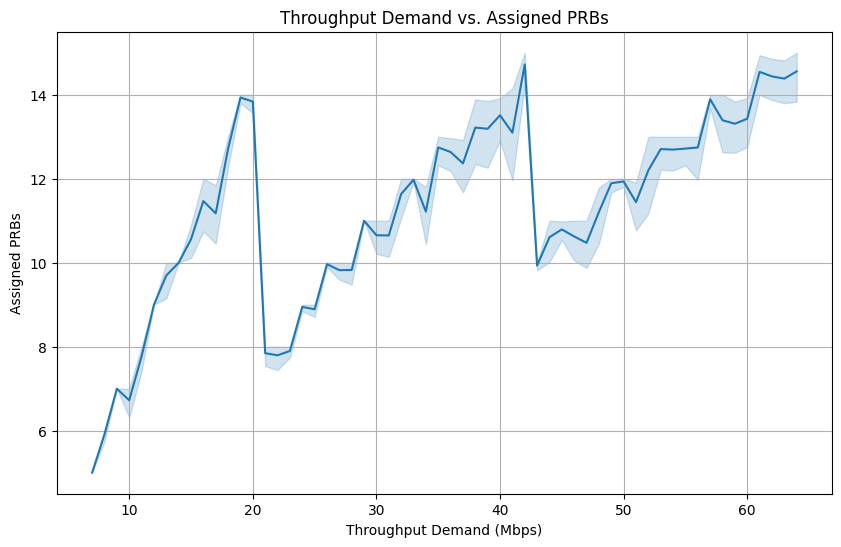

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='AssignedPRBs', data=df_visuals)
plt.title('Throughput Demand vs. Assigned PRBs')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('Assigned PRBs')
plt.grid(True)
plt.show()

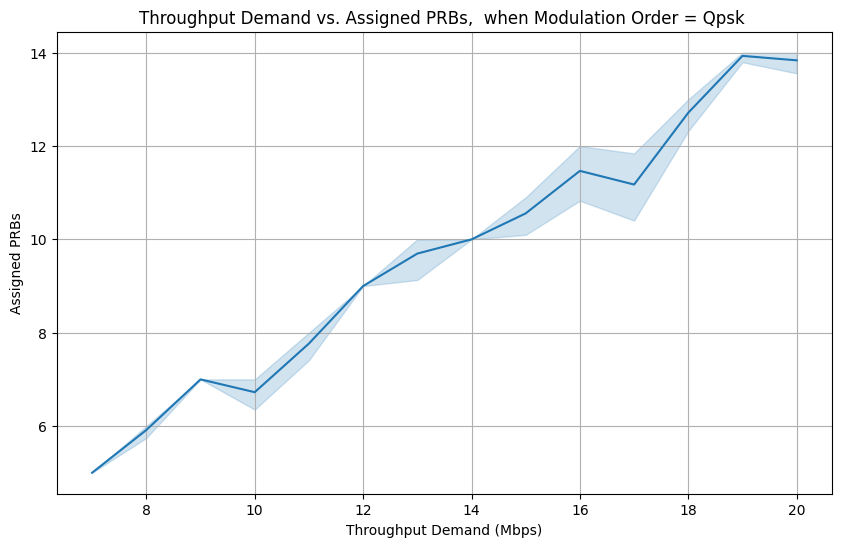

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='AssignedPRBs', data=df_mod_qpsk)
plt.title('Throughput Demand vs. Assigned PRBs,  when Modulation Order = Qpsk ')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('Assigned PRBs')
plt.grid(True)
plt.show()

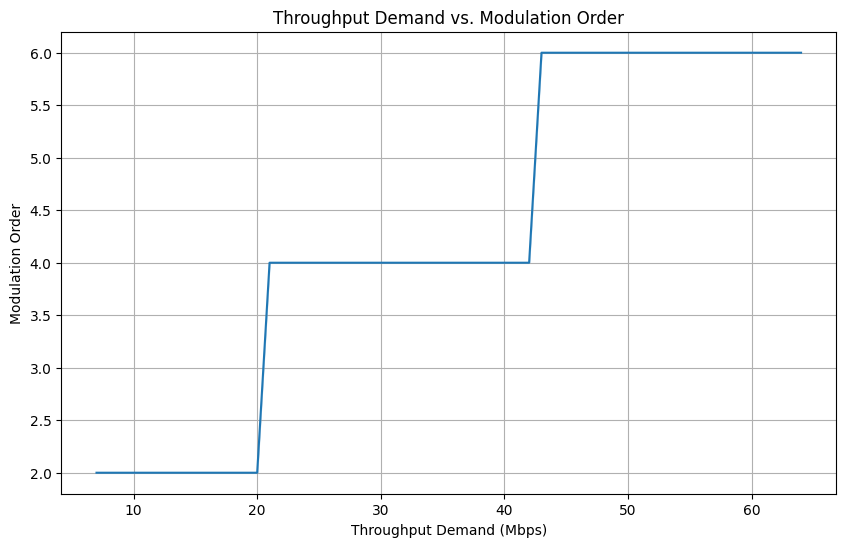

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='MOk', data=df_visuals)
plt.title('Throughput Demand vs. Modulation Order')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('Modulation Order')
plt.grid(True)
plt.show()

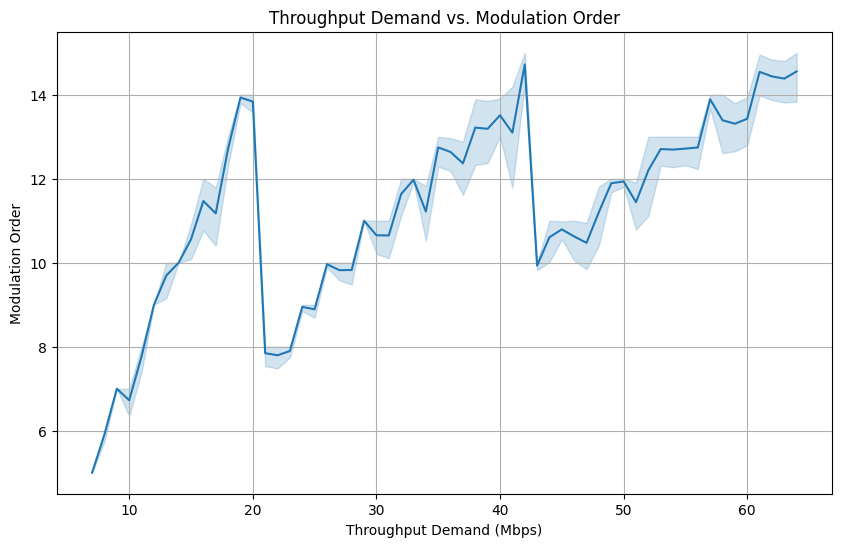

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='AssignedPRBs', data=df_visuals)
plt.title('Throughput Demand vs. Modulation Order')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('Modulation Order')
plt.grid(True)
plt.show()

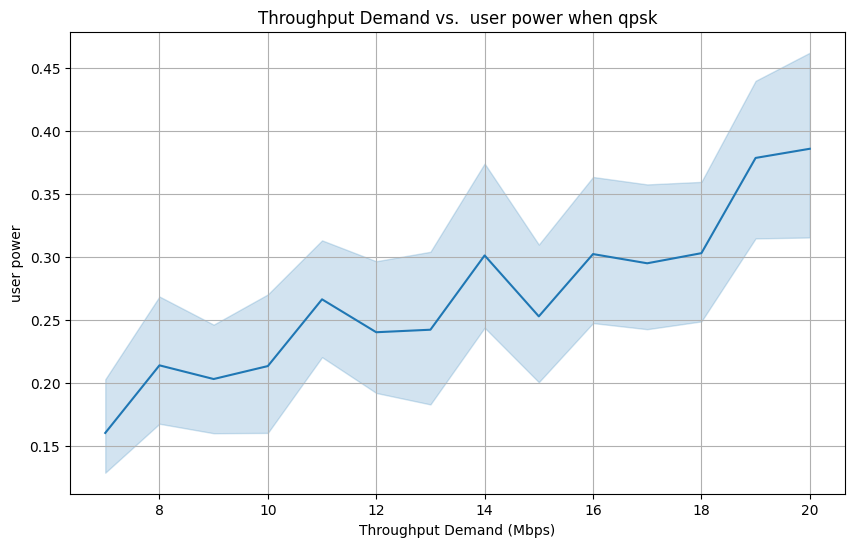

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='TotalPower_W', data=df_mod_qpsk)
plt.title('Throughput Demand vs.  user power when qpsk')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('user power')
plt.grid(True)
plt.show()
# df_mod_qpsk

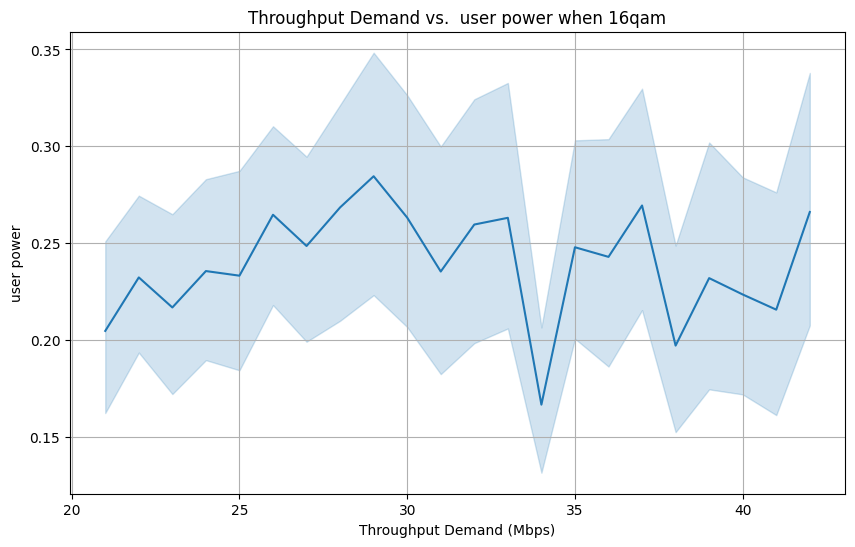

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='TotalPower_W', data=df_16qam)
plt.title('Throughput Demand vs.  user power when 16qam')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('user power')
plt.grid(True)
plt.show()
# df_mod_qpsk

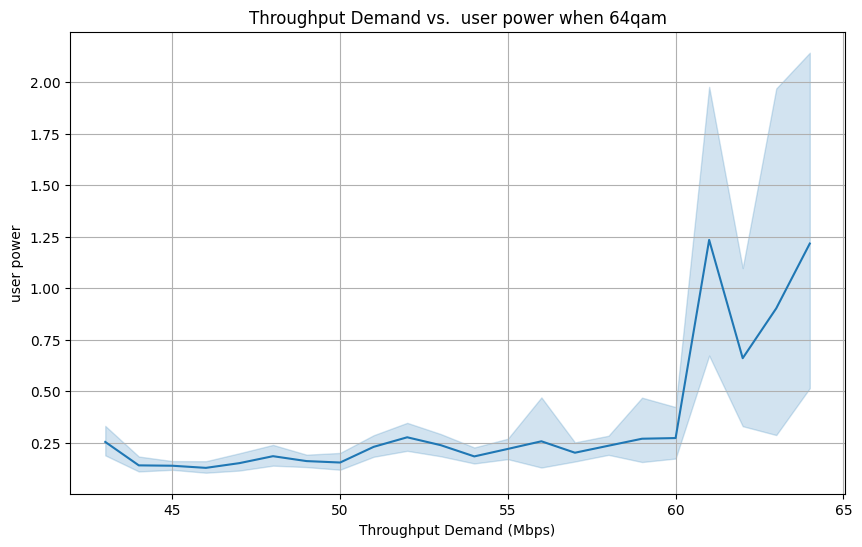

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rk_Mbps', y='TotalPower_W', data=df_64qam)
plt.title('Throughput Demand vs.  user power when 64qam')
plt.xlabel('Throughput Demand (Mbps)')
plt.ylabel('user power')
plt.grid(True)
plt.show()
#

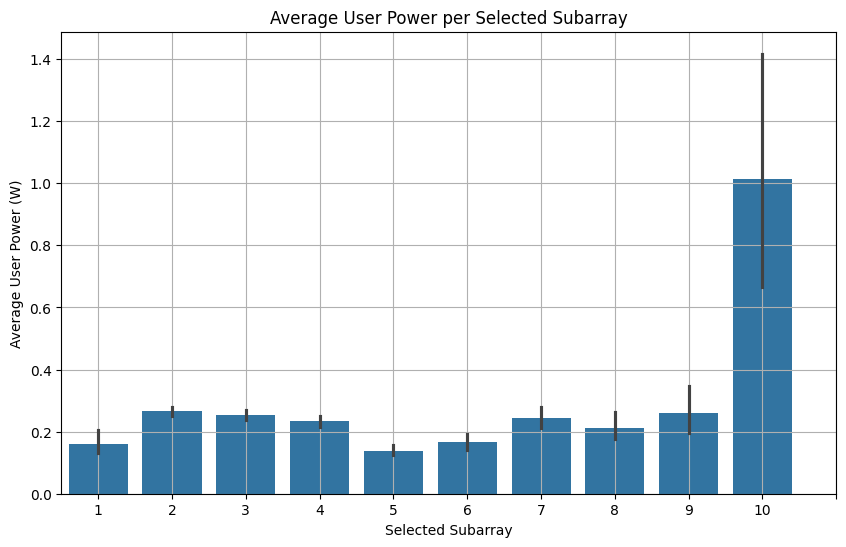

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Select_Subarrays', y='TotalPower_W', data = df_visuals)
plt.title('Average User Power per Selected Subarray')
plt.xlabel('Selected Subarray')
plt.ylabel('Average User Power (W)')
plt.xticks(range(11)) # Ensure all integer ticks from 0 to 10 are shown
plt.grid(True)
plt.show()

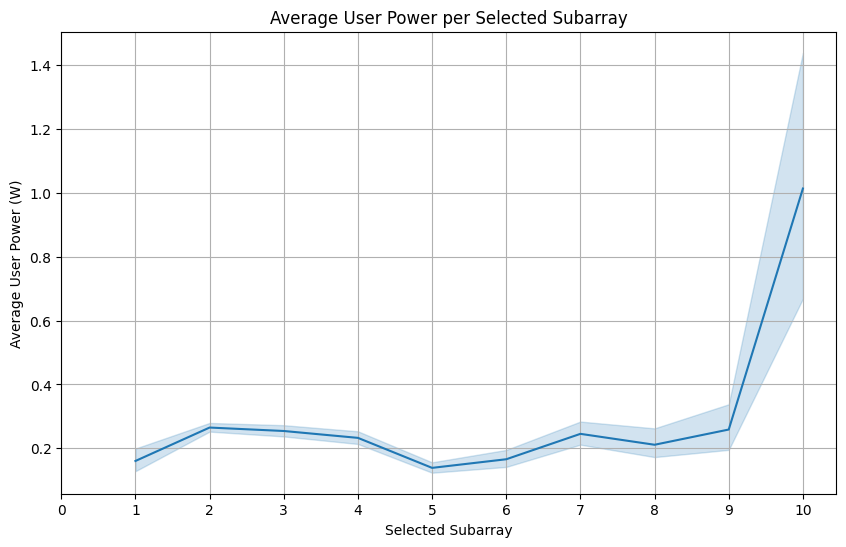

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Select_Subarrays', y='TotalPower_W', data = df_visuals)
plt.title('Average User Power per Selected Subarray')
plt.xlabel('Selected Subarray')
plt.ylabel('Average User Power (W)')
plt.xticks(range(11)) # Ensure all integer ticks from 0 to 10 are shown
plt.grid(True)
plt.show()